# Исследовательский анализ данных в Python и проверка гипотез

### Цели и задачи проекта

<font color='#777778'>
    
**Цель проекта**:
Провести исследовательский анализ данных сервиса Афиша (с 1 июня по 31 октября 2024 года) и проверить продуктовые гипотезы, чтобы объяснить наблюдаемую смену спроса, оценить изменения пользовательских предпочтений и дать практические рекомендации для подготовки к периодам распродаж и новогодних акций.
    
**Задачи проекта**:
1. Загрузить  и подготовить данные.  
2. Провести исследовательский анализ данных:
- Изучить расспределение заказов по различным сегментам (тип мероприятия, тип устройства, категория по возрастному рейтингу) и анализ их сезонных изменений.   
3. Проанализировать активность пользователей осенью 2024 г.
4. Исследовать популярность событий и партнеров осенью 2024 г.
5. Статистический анализ данных:
- Проверка гипотезы о  большей активности пользователей мобильных устройств.

</font>

### Описание данных

<font color='#777778'>
В работе используются данные сервиса Афиша за период 1 июня - 31 октября 2024 года. Доступно три датасета.
    

    
1. `final_tickets_orders_df.csv` — данные о заказах
Содержит информацию о заказах, сделанных через мобильные устройства и ПК.
    
Основные поля:
* `order_id` — идентификатор заказа
* `user_id` — идентификатор пользователя
* `created_dt_msk` — дата оформления заказа
* `created_ts_msk` — дата и время оформления заказа
* `event_id` — идентификатор события
* `cinema_circuit` — сеть кинотеатров
* `age_limit` — возрастное ограничение
* `currency_code` — валюта
* `device_type_canonical` — тип устройства (mobile/desktop)
* `revenue` — выручка заказа
* `service_name` — билетный оператор
* `tickets_count` — количество билетов
* `total` — итоговая сумма заказа
* `days_since_prev` — дни с предыдущего заказа (может быть NaN)
    
2. `final_tickets_events_df.csv` — данные о событиях
    
Основные поля:
* `event_id` — идентификатор события
* `event_name` — название
* `event_type_description` — описание типа
* `event_type_main` — основной тип
* `organizers` — организаторы
* `region_name` — регион
* `city_name` — город
* `venue_id` — идентификатор площадки
* `venue_name` — название площадки
* `venue_address` — адрес.
    
3. `final_tickets_tenge_df.csv` — курс тенге.
Нужен для конвертации заказов, оплаченных в тенге.
Поля:
* `nomina`l — 100 тенге
* `data` — дата курса
* `curs` — курс в рублях за 100 тенге
* `cdx` — код валюты (kzt)</font>

### Содержимое проекта

<font color='#777778'>
    
    
    
1.`Загрузка данных и знакомство с ними`.
    
2.`Предобработка данных`:
- Проверка на пропуски
- Проверка корректности категориальных данных и поиск аномалий
- Проверка на явные и неявные дубли
- Преобразование и оптимизация типов данных
- Создание новых столбцов
3.`Исследовательский анализ данных`:
- Анализ распределения заказов по сегментам и их сезонные изменения
- Осенняя активность пользователей
- Популярные события и партнеры
4. `Статистический анализ данных`:
- Проверка гипотезы о равенстве среднего количества заказов различных устройств
- Проверка гипотезы о равенстве среднего времени между заказами различных устройств
5. `Итоговый вывод и рекомендации`.
</font>

---

## Загрузка данных и знакомство с ними

In [29]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from scipy.stats import mannwhitneyu

In [30]:
# Загрузка данных
df_orders = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_orders_df.csv')
df_events = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_events_df.csv')
df_tenge = pd.read_csv('https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

In [31]:
# Размер данных и типы столбцов
df_orders.info()
# Просмотр первых 5 строк
df_orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0


- В таблице содержится `290 849` записей и `14` столбцов.
- Пропуски обнаружены только в столбце `days_since_prev` — это ожидаемо, так как, если покупки не было, то данные содержат пропуск.
- Столбцы с датой (`created_dt_msk`, `created_ts_msk`) представлены в формате `object` и требуют преобразования в `datetime`.
_______

In [32]:
# Размер данных и типы столбцов
df_events.info()
# Просмотр первых 5 строк
df_events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"


- В таблице содержится `22427` записей и `11` столбцов.
- Пропусков нет.
- Можно изменить разрядность `event_id`, `city_id`, `venue_id` на int32, так как значения не превышают максимальный диапазон.

In [33]:
# Размер данных и типы столбцов
df_tenge.info()
# Просмотр первых 5 строк
df_tenge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


- Объем данных: `357` строк, `4` столбца.
-  Пропусков нет.
- Привести столбец `data` к типу `datetime` - для последующего объединения по дате;

1.**Преобразование типов данных**
- Преобразовать столбцы `created_dt_msk` и `created_ts_msk` из `object` в формат `datetime,` чтобы корректно работать со временем, группировками и фильтрацией.
- Проверить возможность снижения размерности числовых типов (`int64` - `int32`, `float64` - `float32`), если диапазоны значений это позволяют и тем самым уменьшить объем памяти.
2.**Обработка пропусков**
- Проверить наличие пропусков во всех столбцах.
- Убедиться, что кроме `days_since_prev` пропусков нет.При обнаружении пропусков оставить как есть либо заполнить их значением 'unknown''.
3.**Проверка дубликатов**
- Проверить таблицы на наличие явных дубликатов.В случае обнаружения - удалить дубликаты, если это реальные повторения.
4.**Проверка корректности данных**
- Посмотреть финансовые показатели `revenue`, `total` на распределение и наличие выбросов.
- `currency_code` содержит только допустимые валюты (rub / kzt).
- При обнаружении некорректных значений — исправить или удалить строки.

__________

## Предобработка данных и подготовка их к исследованию

### Пропуски

In [34]:
# Проверка на пропущенные значения
display(df_orders.isna().sum())
display(df_events.isna().sum())
display(df_tenge.isna().sum())

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

data       0
nominal    0
curs       0
cdx        0
dtype: int64

Пропуски только в столбце `days_since_prev`. Это допускается, т.к. если не было предыдущей покупки, то данные содержат пропуск.
_________

In [35]:
# Объединяем 2 датасета orders + events
df = df_orders.merge(df_events, on='event_id', how='left')

# Размер данных и типы столбцов
df.info()
# Просмотр первых 5 строк
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290849 entries, 0 to 290848
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                290849 non-null  int64  
 1   user_id                 290849 non-null  object 
 2   created_dt_msk          290849 non-null  object 
 3   created_ts_msk          290849 non-null  object 
 4   event_id                290849 non-null  int64  
 5   cinema_circuit          290849 non-null  object 
 6   age_limit               290849 non-null  int64  
 7   currency_code           290849 non-null  object 
 8   device_type_canonical   290849 non-null  object 
 9   revenue                 290849 non-null  float64
 10  service_name            290849 non-null  object 
 11  tickets_count           290849 non-null  int64  
 12  total                   290849 non-null  float64
 13  days_since_prev         268909 non-null  float64
 14  event_name          

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"


In [36]:
# Проверка на пропущенные значения
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

После объединения таблиц, образовались пропуски. Заменим пропуски на значения 'unknown'.
_____

In [37]:
# Заполняем пропуски заглушками
df['event_name'] = df['event_name'].fillna('unknown')
df['event_type_description'] = df['event_type_description'].fillna('unknown')
df['event_type_main'] = df['event_type_main'].fillna('unknown')
df['organizers'] = df['organizers'].fillna('unknown')
df['region_name'] = df['region_name'].fillna('unknown')
df['city_name'] = df['city_name'].fillna('unknown')
df['venue_name'] = df['venue_name'].fillna('unknown')
df['venue_address'] = df['venue_address'].fillna('unknown')
df['city_id'] = df['city_id'].fillna(-1).astype(int)
df['venue_id'] = df['venue_id'].fillna(-1).astype(int)

In [38]:
# Проверяем пропуски
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                    0
event_type_description        0
event_type_main               0
organizers                    0
region_name                   0
city_name                     0
city_id                       0
venue_id                      0
venue_name                    0
venue_address                 0
dtype: int64

Пропуски в данных отсутствуют.
_______

###  Дубликаты

In [39]:
# Проверка явных дубликатов
df.duplicated().sum()

0

In [40]:
# Удаляем неявные дубликаты (совпадающие по всем столбцам, кроме order_id),
# чтобы статистика отражала реальные уникальные заказы и не искажала анализ
# Сохраняем количество строк до удаления дубликатов
total_rows = len(df)

# Выбираем все столбцы, кроме order_id, для проверки неявных дубликатов
subset_cols = df.columns.drop('order_id')
df = df.drop_duplicates(subset=subset_cols, keep='first')


# Выводим количество удаленных неявных дубликатов
final_rows = len(df)

print(f'Неявных дубликатов удалено: {total_rows - final_rows}')
print(f'Осталось записей: {final_rows}')

Неявных дубликатов удалено: 30
Осталось записей: 290819


Неявные дубликаты — это строки, совпадающие по всем полям кроме уникального order_id. Их удаляем, чтобы статистика отражала реальные заказы и не искажала метрики (количество заказов, средний чек, выручку, активных пользователей).
___

### Категориальные данные

Проверим категориальные данные. В итоговом датафрейме для проверки корректности категориальных данных нас интересует 9 столбцов:
* `cinema_circuit`,
* `currency_code`,
* `device_type_canonical`,
* `service_name`,
* `event_type_description`,
* `event_type_main`,
* `region_name`,
* `city_name`,
* `venue_name`.

In [41]:
# Выведем уникальные значения в ключевых категориальных столбцах
categorical_columns = [
    'cinema_circuit', 'currency_code', 'device_type_canonical',
    'service_name', 'event_type_main', 'region_name', 'city_name', 'venue_name', 'event_type_description'
]

for col in categorical_columns:
    print(f"Столбец {col}: {df[col].nunique()} уникальных значений")
    print(df[col].value_counts().head(10), "\n")

Столбец cinema_circuit: 6 уникальных значений
нет           289421
Другое          1261
КиноСити         122
Москино            7
Киномакс           7
ЦентрФильм         1
Name: cinema_circuit, dtype: int64 

Столбец currency_code: 2 уникальных значений
rub    285750
kzt      5069
Name: currency_code, dtype: int64 

Столбец device_type_canonical: 2 уникальных значений
mobile     232658
desktop     58161
Name: device_type_canonical, dtype: int64 

Столбец service_name: 36 уникальных значений
Билеты без проблем    63696
Лови билет!           41122
Билеты в руки         40359
Мой билет             34840
Облачко               26642
Лучшие билеты         17793
Весь в билетах        16849
Прачечная             10273
Край билетов           6207
Тебе билет!            5227
Name: service_name, dtype: int64 

Столбец event_type_main: 8 уникальных значений
концерты    115272
театр        67313
другое       65855
спорт        21906
стендап      13393
выставки      4853
ёлки          1989
unknown  

Категориальные признаки заполнены корректно, данные осмысленные. В столбцах `cinema_circuit` и `event_type_main` встречаются значения, которые фактически являются метками отсутствия данных:
-  `нет` - отсутствие информации о сети кинотеатров
- `unknown` - отсутствие информации о типе события.
Ошибок и некорректных категорий больше не выявлено.
_____

### Количественные данные

Основной интерес представляли следующие столбцы:
- `revenue` — выручка заказа;
- `tickets_count` — количество билетов в заказе;
-  `total`, `age_limit` — вспомогательные числовые характеристики.
______

Посмотрим на статистические данные, выбросы и распределения в столбцах.

______

In [42]:
# Анализ распределения выручки (revenue)
display(df['revenue'].describe(percentiles=[.95, .99]))

#Анализ количества билетов в заказе (tickets_count)
display(df['tickets_count'].describe(percentiles=[.95, .99]))

# Анализ общей суммы заказа (total)
display(df['total'].describe(percentiles=[.95, .99]))

# Анализ возрастного ограничения (age_limit)
display(df['age_limit'].describe(percentiles=[.95, .99]))

count    290819.000000
mean        625.112946
std        1227.368227
min         -90.760000
50%         355.340000
95%        1744.990000
99%        4000.190000
max       81174.540000
Name: revenue, dtype: float64

count    290819.000000
mean          2.754256
std           1.170461
min           1.000000
50%           3.000000
95%           5.000000
99%           6.000000
max          57.000000
Name: tickets_count, dtype: float64

count    290819.000000
mean       7526.802288
std       15328.956797
min        -358.850000
50%        4771.390000
95%       17858.981000
99%       61647.160000
max      811745.400000
Name: total, dtype: float64

count    290819.000000
mean         10.211499
std           6.518034
min           0.000000
50%          12.000000
95%          18.000000
99%          18.000000
max          18.000000
Name: age_limit, dtype: float64

- Выручка  `revenue ` имеет ярко выраженный правосторонний хвост и содержит отрицательные значения, которые также относятся к выбросам. Отрицательные значения возможны из-за:
- возвраты,
- отмены заказов,
- корректировки транзакций.
- Количество билетов  `tickets_count`  содержит большинство 1-3 билета. Значения выше 6 считаются редкими.
-  `total ` повторяет распределение  `revenue ` с учетом количества билетов, а отрицательные значения возвраты или отмены.
-  `age_limit ` фиксированное распределение 0-18, медиана - 12.
________

In [43]:
# Разделим выручку на рубли и тенге
rub_df = df[df['currency_code'] == 'rub'].copy()
kzt_df = df[df['currency_code'] == 'kzt'].copy()

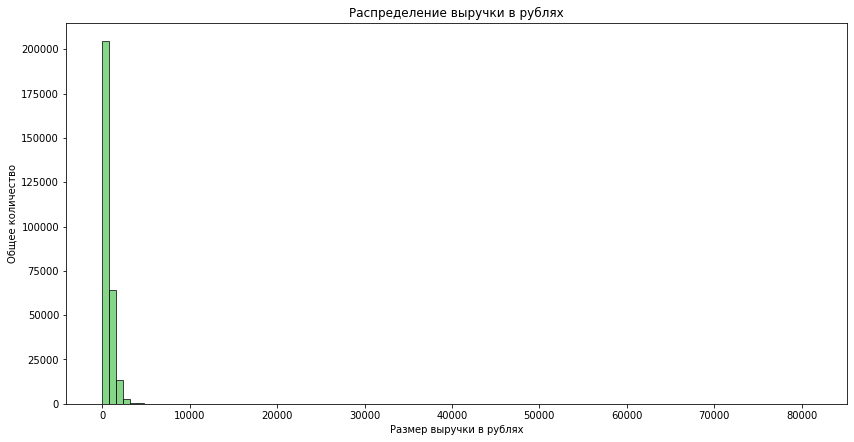

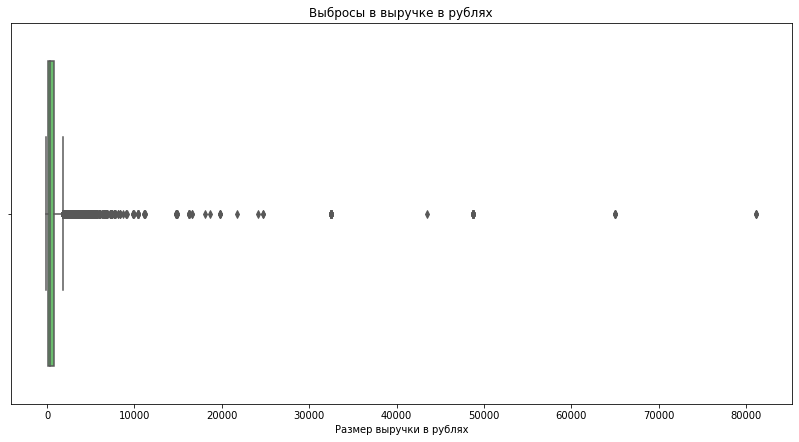

In [44]:
# Визуализация распределений
# Выручка в рублях
plt.figure(figsize=(14, 7))
sns.histplot(data=rub_df, x='revenue', bins=100, color='#5ec962')
plt.title('Распределение выручки в рублях')
plt.xlabel('Размер выручки в рублях')
plt.ylabel('Общее количество')

plt.figure(figsize=(14, 7))
sns.boxplot(x=rub_df['revenue'], color='#5ec962')
plt.title('Выбросы в выручке в рублях')
plt.xlabel('Размер выручки в рублях');

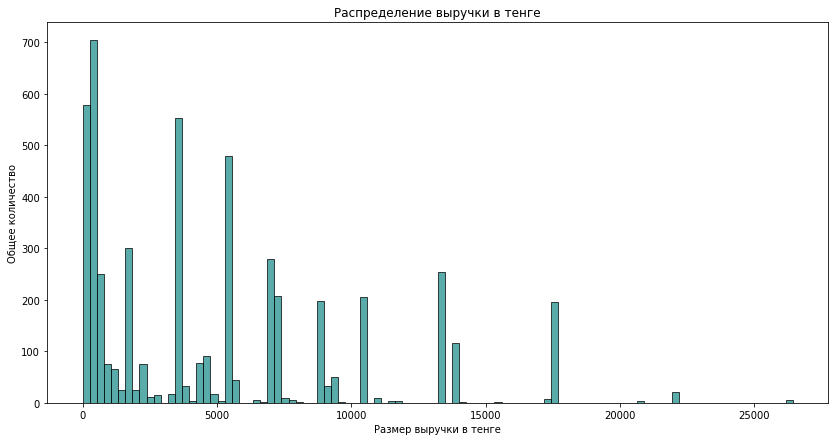

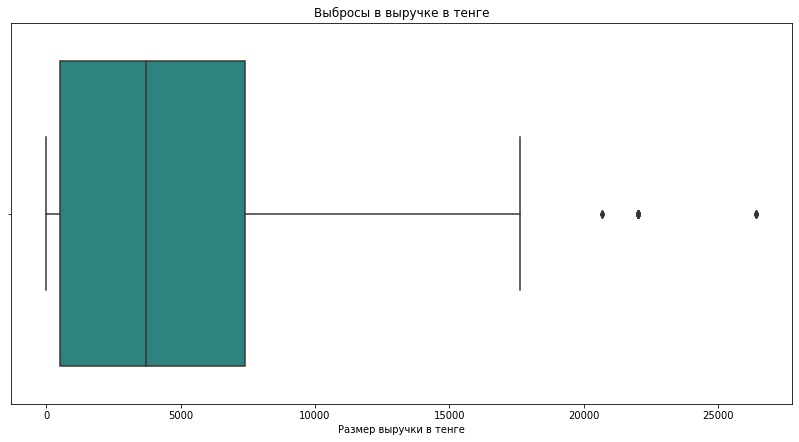

In [45]:
# Выручка в тенге
plt.figure(figsize=(14, 7))
sns.histplot(data=kzt_df, x='revenue', bins=100, color='#21918c')
plt.title('Распределение выручки в тенге')
plt.xlabel('Размер выручки в тенге')
plt.ylabel('Общее количество')


plt.figure(figsize=(14, 7))
sns.boxplot(x=kzt_df['revenue'], color='#21918c')
plt.title('Выбросы в выручке в тенге')
plt.xlabel('Размер выручки в тенге');

Обнаружены выбросы в выручке с заказа `revenue`, поэтому отбераем  значения по 99-му процентилю.
________

In [46]:
# 99-й процентиль для каждой валюты
rub_revenue_99perc = rub_df['revenue'].quantile(0.99)
kzt_revenue_99perc = kzt_df['revenue'].quantile(0.99)

# Фильтрация
rub_df_filtered = rub_df[rub_df['revenue'] <= rub_revenue_99perc]
kzt_df_filtered = kzt_df[kzt_df['revenue'] <= kzt_revenue_99perc]

# Объединение обратно
df_f = pd.concat([rub_df_filtered, kzt_df_filtered])

print(f"99-й процентиль для RUB: {rub_revenue_99perc:.2f}")
print(f"99-й процентиль для KZT: {kzt_revenue_99perc:.2f}")
print(f"Размер исходного датасета: {len(df)}")
print(f"Размер отфильтрованного датасета: {len(df_f)}")
print(f"Удалено записей: {len(df) - len(df_f)}")

99-й процентиль для RUB: 2569.60
99-й процентиль для KZT: 17617.24
Размер исходного датасета: 290819
Размер отфильтрованного датасета: 287932
Удалено записей: 2887


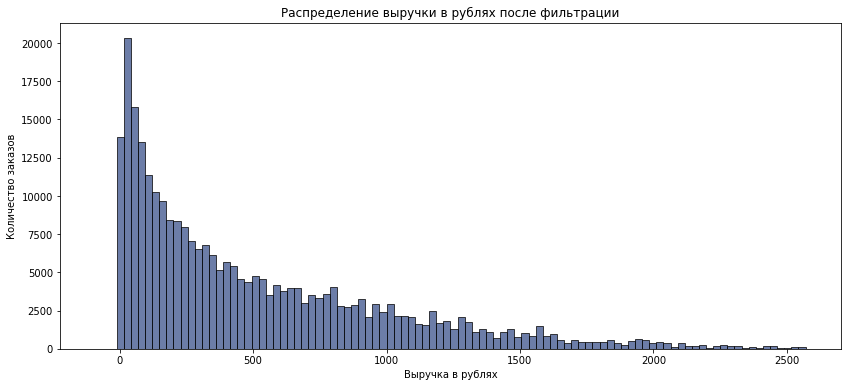

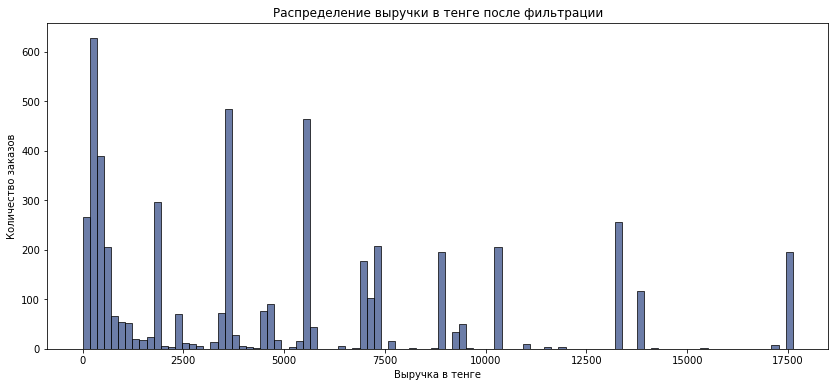

In [47]:
# Визуализация после фильтрации
plt.figure(figsize=(14, 6))
sns.histplot(rub_df_filtered['revenue'], bins=100, color='#3b528b')
plt.title('Распределение выручки в рублях после фильтрации')
plt.xlabel('Выручка в рублях')
plt.ylabel('Количество заказов')
plt.show()

plt.figure(figsize=(14, 6))
sns.histplot(kzt_df_filtered['revenue'], bins=100, color='#3b528b')
plt.title('Распределение выручки в тенге после фильтрации')
plt.xlabel('Выручка в тенге')
plt.ylabel('Количество заказов')
plt.show()


- Выручка `revenue` и количество билетов `tickets_count` имеют выраженные выбросы: средние значения значительно выше медианы.
- Большинство заказов содержит 1- 3 билета; значения выше 6 встречаются редко.
- Отрицательные значения `revenue` и `tota`l связаны с возвратами и отменами заказов.
- После фильтрации по 99-му процентилю удалены экстремальные значения выручки: `RUB ≤ 2 569.59`, `KZT ≤ 17 617.24`.
- Распределение выручки по валютам визуализировано отдельными гистограммами и boxplot, что позволяет корректно оценивать данные и выявлять выбросы.
- Датасет после фильтрации уменьшился примерно на 1%, сохранив основную часть информации.

### Преобразование типов данных

In [48]:
df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
df['age_limit'] = pd.to_numeric(df['age_limit'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')
df['days_since_prev'] = pd.to_numeric(df['days_since_prev'], downcast='integer')
df['revenue'] = pd.to_numeric(df['revenue'], downcast='float')
df['total'] = pd.to_numeric(df['total'], downcast='float')
df_tenge['nominal'] = pd.to_numeric(df_tenge['nominal'], downcast='integer')
df_tenge['curs'] = pd.to_numeric(df_tenge['curs'], downcast='float')
df_tenge['data'] = pd.to_datetime(df_tenge['data'])

# Проверим результат
print(df.dtypes)
print(df_tenge.dtypes)

order_id                           int64
user_id                           object
created_dt_msk            datetime64[ns]
created_ts_msk            datetime64[ns]
event_id                           int64
cinema_circuit                    object
age_limit                           int8
currency_code                     object
device_type_canonical             object
revenue                          float32
service_name                      object
tickets_count                       int8
total                            float32
days_since_prev                  float64
event_name                        object
event_type_description            object
event_type_main                   object
organizers                        object
region_name                       object
city_name                         object
city_id                            int64
venue_id                           int64
venue_name                        object
venue_address                     object
dtype: object
da

Типы данных приведены к оптимальным форматам `int16`, `int32`, `float32`, `datetime`, что снизило потребление памяти и подготовило данные к дальнейшему анализу. Дата и время приведены к типу datetime64.
_____

### Создание новых столбцов

Соединим датасеты и приведем выручку с заказа к единой валюте — российскому рублю.
Создадим новые столбцы:
- `revenue_rub` — выручка с заказа в российском рубле;
- `one_ticket_revenue_rub` — выручка с продажи одного билета на мероприятие;
- `month` — месяц оформления заказа;
- `season` — столбец с информацией о сезонности, включая такие категории, как: 'лето', 'осень', 'зима', 'весна'.
_________

In [49]:
df = df.merge(
df_tenge[['data', 'curs']],
left_on=df['created_dt_msk'].dt.date,
right_on=df_tenge['data'].dt.date,
how='left')
df['revenue_rub'] = np.where(
df['currency_code'] == 'kzt',
df['revenue'] * (df['curs'] / 100),
df['revenue'])
df['one_ticket_revenue_rub'] = df['revenue_rub'] / df['tickets_count']
df['month'] = df['created_dt_msk'].dt.month

In [50]:
def season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

# Применяем функцию к столбцу 'month'
df['season'] = df['month'].apply(season)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 290819 entries, 0 to 290818
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   key_0                   290819 non-null  object        
 1   order_id                290819 non-null  int64         
 2   user_id                 290819 non-null  object        
 3   created_dt_msk          290819 non-null  datetime64[ns]
 4   created_ts_msk          290819 non-null  datetime64[ns]
 5   event_id                290819 non-null  int64         
 6   cinema_circuit          290819 non-null  object        
 7   age_limit               290819 non-null  int8          
 8   currency_code           290819 non-null  object        
 9   device_type_canonical   290819 non-null  object        
 10  revenue                 290819 non-null  float32       
 11  service_name            290819 non-null  object        
 12  tickets_count           290819

Новые столбцы (`revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`) успешно созданы. Данные приведены к единой валют.Датасет готов к дальнейшему анализу по выручке, активности пользователей и сезонным трендам.
_____

В ходе предобработки данных выполнено следующее:
1.	`Пропуски:` выявлены только в столбце `days_since_prev`, остальные пропуски в объединенном датасете заполнены заглушками ('unknown' для категориальных, -1 для идентификаторов).
2.	`Дубликаты`: явные отсутствуют, неявные удалены (30 записей).
3.	`Категориальные данные:` проверены, значения корректны, метки отсутствия информации (нет, unknown) учтены.
4.	`Количественные данные:` выявлены выбросы в `revenue`, `total` и `tickets_count` поэтому  проведена фильтрация по 99-му процентилю, что позволило удалить экстремальные значения`1% записей`.
5.	`Типы данных`: оптимизированы для экономии памяти (int8, float32, datetime64).
6.	`Новые столбцы`: созданы `revenue_rub`, `one_ticket_revenue_rub`, `month`, `season`а.
_____

## Исследовательский анализ данных

### Анализ распределения заказов по сегментам и их сезонные изменения

Начнем анализ с месячной динамики заказов
___

In [52]:
# Количество заказов по месяцам
orders_by_month = df.groupby('month')['order_id'].count().reset_index()
orders_by_month.rename(columns={'order_id': 'orders_count'}, inplace=True)

display(orders_by_month)

,month,orders_count
0,6,34676
1,7,40924
2,8,45037
3,9,69973
4,10,100209


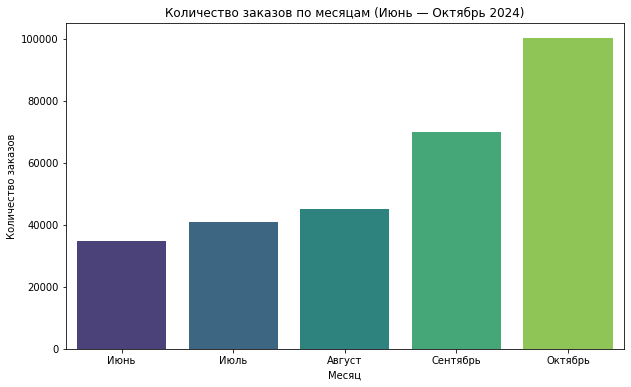

In [53]:
# Список меток месяцев на русском языке
month_labels = ['Июнь', 'Июль', 'Август', 'Сентябрь', 'Октябрь']

plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='orders_count', data=orders_by_month, palette="viridis")

# Подписи осей и заголовок
plt.title('Количество заказов по месяцам (Июнь — Октябрь 2024)')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

# Подписи месяцев на русском языке
plt.xticks(ticks=range(len(month_labels)), labels=month_labels)
plt.show()

- С июня по октябрь 2024 года наблюдается стабильный рост количества заказов: от `34 676` в июне до `100 209` в октябре.
- Наибольший скачок приходится на сентябрь-октябрь, что может быть связано с сезонными мероприятиями или маркетинговыми активностями.
- Месячная динамика явно отражает сезонный рост спроса, и эти данные можно использовать для планирования промоакций и загрузки сервисов.
________

Рассмотрим распределение заказов билетов по разным категориям:
- тип мероприятия,
- тип устройства,
- категория мероприятия по возрастному рейтингу.
Начнем с типов мероприятий `event_type_main`:
_______

,event_type_main,share,season
0,концерты,0.427216,Лето
1,другое,0.269967,Лето
2,театр,0.200676,Лето
3,стендап,0.053060,Лето
4,спорт,0.024976,Лето
5,выставки,0.020027,Лето
6,ёлки,0.002288,Лето
7,unknown,0.001790,Лето
0,концерты,0.374505,Осень
1,театр,0.253282,Осень


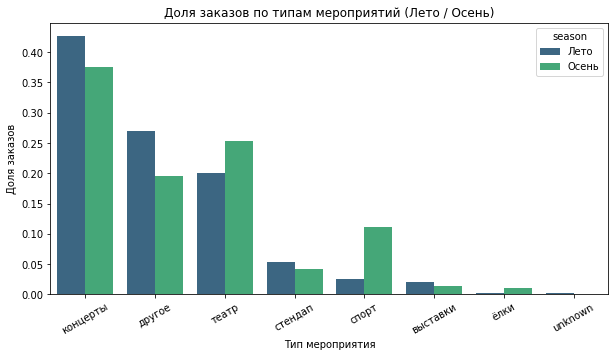

In [54]:
# Фильтруем лето и осень
summer = df[df['month'].isin([6, 7, 8])]
autumn = df[df['month'].isin([9, 10])]

# Считаем доли типов мероприятий
summer_event = summer['event_type_main'].value_counts(normalize=True).reset_index()
summer_event['season'] = 'Лето'

autumn_event = autumn['event_type_main'].value_counts(normalize=True).reset_index()
autumn_event['season'] = 'Осень'

# Переименовываем столбцы
summer_event.columns = ['event_type_main', 'share', 'season']
autumn_event.columns = ['event_type_main', 'share', 'season']

# Объединяем в один датафрейм
event_data = pd.concat([summer_event, autumn_event])

display(event_data)
# График
plt.figure(figsize=(10, 5))
sns.barplot(data=event_data, x='event_type_main', y='share', hue='season', palette='viridis')

plt.title('Доля заказов по типам мероприятий (Лето / Осень)')
plt.xlabel('Тип мероприятия')
plt.ylabel('Доля заказов')
plt.xticks(rotation=30)
plt.show()

- В летний период наибольшая доля заказов приходится на концерты `42,7%`, затем идут другое `27%` и театр `20%`.
- Осенью доля концертов снижается до `37,5%`, а доля заказов на театр и спорт увеличивается, что говорит о смещении интересов пользователей к более спокойным мероприятиям.
_________

,device_type,share,season
0,mobile,0.805408,Лето
1,desktop,0.194592,Лето
0,mobile,0.796183,Осень
1,desktop,0.203817,Осень


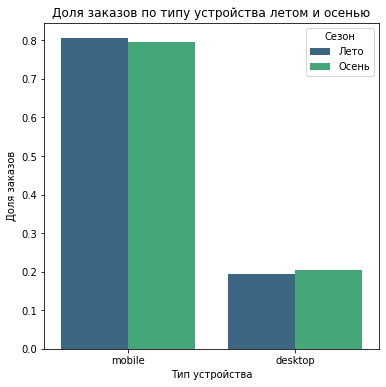

In [55]:
# Подготовка данных
summer_device = summer['device_type_canonical'].value_counts(normalize=True).reset_index()
summer_device.columns = ['device_type', 'share']
summer_device['season'] = 'Лето'

autumn_device = autumn['device_type_canonical'].value_counts(normalize=True).reset_index()
autumn_device.columns = ['device_type', 'share']
autumn_device['season'] = 'Осень'

device_data = pd.concat([summer_device, autumn_device])
display(device_data)

# Визуализация
plt.figure(figsize=(6, 6))
sns.barplot(x='device_type', y='share', hue='season', data=device_data, palette="viridis")
plt.title('Доля заказов по типу устройства летом и осенью')
plt.ylabel('Доля заказов')
plt.xlabel('Тип устройства')
plt.legend(title='Сезон')
plt.show()

- Доля мобильных устройств высокая, как летом, так и осенью около `80%`.
- Доля десктопов чуть увеличивается осенью `20,4% ` и `19,5%` летом, что может быть связано с увеличением онлайн-заказов через рабочие компьютеры в осенний период.
________

Категория мероприятия по возрастному рейтингу  `age_limit`:
________

,age_limit,share,season
0,0,0.179141,Лето
1,6,0.182117,Лето
2,12,0.206181,Лето
3,16,0.282111,Лето
4,18,0.150451,Лето
0,0,0.234255,Осень
1,6,0.177434,Осень
2,12,0.221404,Осень
3,16,0.261743,Осень
4,18,0.105164,Осень


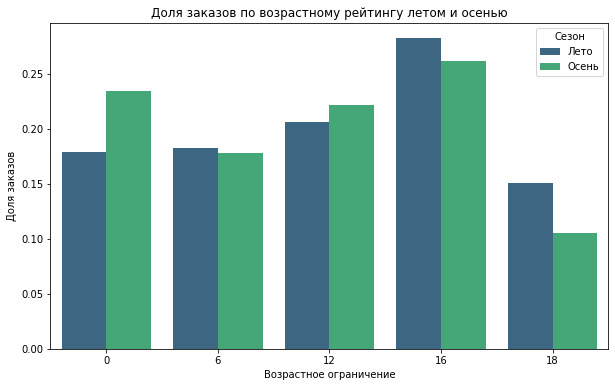

In [78]:
# Подготовка данных
summer_age = summer['age_limit'].value_counts(normalize=True).sort_index().reset_index()
summer_age.columns = ['age_limit', 'share']
summer_age['season'] = 'Лето'

autumn_age = autumn['age_limit'].value_counts(normalize=True).sort_index().reset_index()
autumn_age.columns = ['age_limit', 'share']
autumn_age['season'] = 'Осень'

age_data = pd.concat([summer_age, autumn_age])
display(age_data)

# Визуализация
plt.figure(figsize=(10, 6))
sns.barplot(x='age_limit', y='share', hue='season', data=age_data, palette="viridis")
plt.title('Доля заказов по возрастному рейтингу летом и осенью')
plt.ylabel('Доля заказов')
plt.xlabel('Возрастное ограничение')
plt.legend(title='Сезон')
plt.show() 

- Летний период характеризуется наибольшей долей заказов на мероприятия с возрастным ограничением 16 лет `28,2%`, затем идут 12 лет и 6 лет.
- Осенью наблюдается рост доли заказов на мероприятия для младшей аудитории (0 лет) и снижение доли для старших возрастов (18 лет).
- Это может отражать сезонные изменения предпочтений: летом чаще посещают мероприятия для подростков и взрослых, а осенью увеличивается доля семейных посещений.
_____

Изменение выручки с продажи одного билета:
_____

season,Лето,Осень
event_type_main,,
unknown,3.611663,15.055037
выставки,86.416199,91.066620
другое,81.088707,77.097946
концерты,319.079498,286.763214
спорт,54.112064,52.139439
стендап,227.070679,249.963867
театр,222.524551,183.053375
ёлки,276.388214,234.503845


,"Изменение средней выручки, %"
event_type_main,
unknown,316.845032
стендап,10.081970
выставки,5.381417
спорт,-3.645444
другое,-4.921478
концерты,-10.127974
ёлки,-15.154182
театр,-17.737896


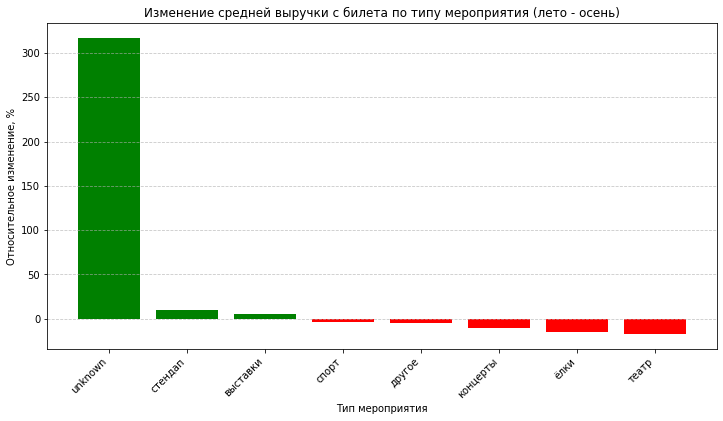

In [77]:
# Средняя выручка с одного билета по типу мероприятия и сезону
mean_revenue = df.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].mean().unstack()
display(mean_revenue)

# Рассчитаем относительное изменение средней выручки: осень относительно лета
revenue_change = (mean_revenue['Осень'] / mean_revenue['Лето'] - 1) * 100
revenue_change = revenue_change.sort_values(ascending=False).to_frame('Изменение средней выручки, %')
display(revenue_change)

plt.figure(figsize=(12, 6))

# Значение цветов: зеленый для роста, красный для падения
colors = np.where(revenue_change['Изменение средней выручки, %'] > 0, 'green', 'red')

plt.bar(revenue_change.index, revenue_change['Изменение средней выручки, %'], color=colors)

plt.title('Изменение средней выручки с билета по типу мероприятия (лето - осень)')
plt.xlabel('Тип мероприятия')
plt.ylabel('Относительное изменение, %')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

- С июня по октябрь 2024 года количество заказов стабильно росло, с резким ростом в сентябре-октябре.
- Летом лидировали концерты, осенью увеличилась доля театра и спорта.
- Около 80% заказов совершались с мобильных устройств.
- Возрастная аудитория смещалась к младшим  от лета к осени.
- Средняя выручка с билета изменялась по типу мероприятий: рост у стендапа,  было выявлено падение у театра, концертов и «елок».
- Сезонность существенно влияет на спрос, состав аудитории и выручку.
_____

### Осенняя активность пользователей

In [58]:
#  Осень 2024
df_autumn = df[
    (df['season'] == 'Осень') &
    (df['created_dt_msk'].dt.year == 2024)
].copy()

# Агрегация по дням
df_autumn['date'] = df_autumn['created_dt_msk'].dt.date

daily = df_autumn.groupby('date').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Количество заказов на одного пользователя.
daily['orders_per_user'] = daily['orders'] / daily['dau']

display(daily.head())

,date,orders,dau,avg_price,orders_per_user
0,2024-09-01,1348,569,208.117508,2.369069
1,2024-09-02,1391,580,195.536087,2.398276
2,2024-09-03,5124,783,82.095428,6.544061
3,2024-09-04,1785,688,184.003357,2.594477
4,2024-09-05,1960,745,194.513168,2.630872


**График 1 Количество заказов по дням**
______

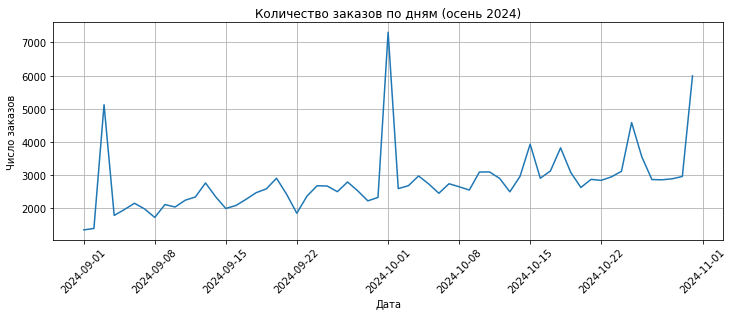

In [59]:
plt.figure(figsize=(12, 4))
plt.plot(daily['date'], daily['orders'])
plt.title('Количество заказов по дням (осень 2024)')
plt.xlabel('Дата')
plt.ylabel('Число заказов')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**График 2 DAU — количество активных пользователей по дням**
______

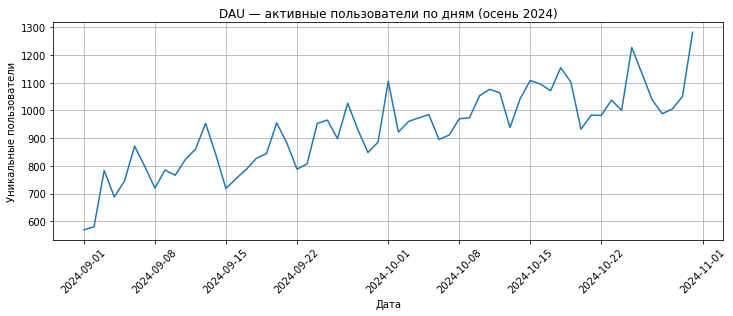

In [60]:
plt.figure(figsize=(12, 4))
plt.plot(daily['date'], daily['dau'])
plt.title('DAU — активные пользователи по дням (осень 2024)')
plt.xlabel('Дата')
plt.ylabel('Уникальные пользователи')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**График 3 Среднее число заказов на пользователя**
____

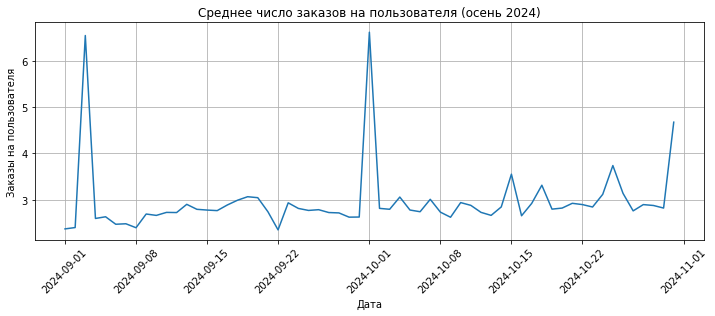

In [61]:
plt.figure(figsize=(12, 4))
plt.plot(daily['date'], daily['orders_per_user'])
plt.title('Среднее число заказов на пользователя (осень 2024)')
plt.xlabel('Дата')
plt.ylabel('Заказы на пользователя')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

**График 4 Средняя стоимость одного билета**
____

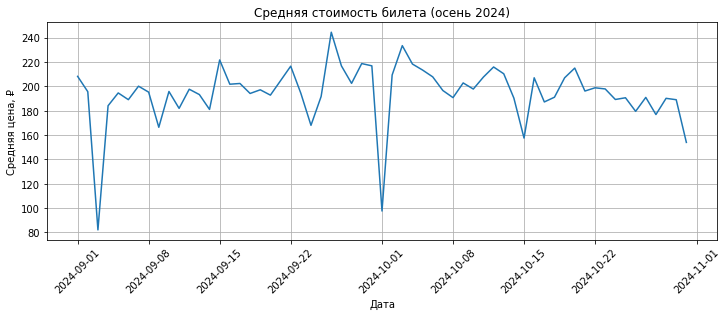

In [62]:
plt.figure(figsize=(12, 4))
plt.plot(daily['date'], daily['avg_price'])
plt.title('Средняя стоимость билета (осень 2024)')
plt.xlabel('Дата')
plt.ylabel('Средняя цена, ₽')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

In [63]:
# Изучаем недельную цикличность
# Фильтруем осень
df_autumn = df[
    (df['season'] == 'Осень') &
    (df['created_dt_msk'].dt.year == 2024)
].copy() 

# Дни недели на английском языке
df_autumn['weekday_eng'] = df_autumn['created_dt_msk'].dt.day_name()

# Перевод на русский язык
week_map = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}
df_autumn['weekday'] = df_autumn['weekday_eng'].map(week_map)

# Группировка
weekly = df_autumn.groupby('weekday').agg(
    orders=('order_id', 'count'),
    dau=('user_id', 'nunique'),
    avg_price=('one_ticket_revenue_rub', 'mean')
).reset_index()

# Задаtм правильный порядок дней недели
weekday_order = [
    'Понедельник', 'Вторник', 'Среда',
    'Четверг', 'Пятница', 'Суббота', 'Воскресенье'
]

weekly['weekday'] = pd.Categorical(weekly['weekday'], categories=weekday_order, ordered=True)

# Сортируем по дням недели
weekly = weekly.sort_values('weekday').reset_index(drop=True)

# Расчет количества заказов на пользователя
weekly['orders_per_user'] = weekly['orders'] / weekly['dau']

display(weekly)

,weekday,orders,dau,avg_price,orders_per_user
0,Понедельник,21713,4477,192.414169,4.849899
1,Вторник,31736,4817,147.483109,6.588333
2,Среда,23125,4852,195.915222,4.766076
3,Четверг,27394,4998,193.389664,5.480992
4,Пятница,25090,4898,199.319244,5.122499
5,Суббота,21544,4598,200.127594,4.685515
6,Воскресенье,19580,4415,208.932785,4.434881


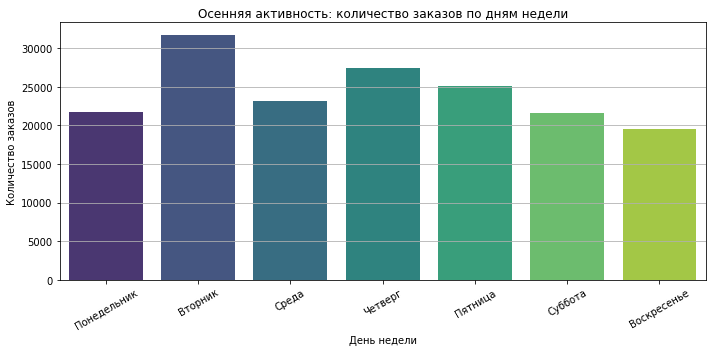

In [64]:
plt.figure(figsize=(10, 5))
sns.barplot(data=weekly, x='weekday', y='orders', palette="viridis")

plt.title('Осенняя активность: количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.xticks(rotation=30)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

1. `Дневная динамика`:
- По графику 'Количество заказов по дням' виден тренд на рост числа заказов осенью с несколькими большими пиками `2024-09-01`, `2024-10-01`, `2024-10-31`. Возможно в это время были акционные предложения, что отразилос на графике пиком заказов.
- Число активных пользователей (DAU) показывает позитивную динамику.На графике виден растущий тренд.С начала сентяря к концу октября показатель вырос  от `600-700` до `1100-1200`.
- Среднее число заказов на одного пользователя относительно стабильно, но есть всплески в отдельные дни, что может быть связано с акциями или выходными.
- Средняя стоимость билета имеет провалы как раз в те даты, где пики по числу заказов, из этого мы можем предположить, что на это оказало внияние маркетинговая акция, связаная со скидкой на количество билетов. Однако с середины  2`024-10-15` идет спад.
2. `Недельная цикличность`:
- Активность пользователей выше в будние дни (особенно во вторник и четверг) и ниже в выходные (суббота и воскресенье).
- Количество заказов на пользователя также выше в будние дни, что говорит об активности в рабочии дни недели.
- В выходные пользователи делают меньше заказов, хотя средняя стоимость билета слегка выше, возможно, из-за выбора более дорогих мероприятий.

`Вывод`: Пользователи проявляют более высокую активность в будние дни, тогда как в выходные наблюдается спад заказов и числа активных пользователей. Эта информация может быть использована для планирования и проведения  маркетинговых кампаний и рекламных акций.

### Популярные события и партнёры

Выделим `ТOП 10 регионов и партнеров`, которые вносят наибольший вклад в выручку.
______

In [65]:
# ТOП 10 регионов

region_stats = df_autumn.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),  # количество уникальных мероприятий
    total_orders=('order_id', 'count'),     # общее количество заказов
    unique_users=('user_id', 'nunique')     # количество уникальных пользователей
).reset_index()

# Расчет долей
region_stats['share_events'] = (region_stats['unique_events'] / region_stats['unique_events'].sum() * 100).round(2)
region_stats['share_orders'] = (region_stats['total_orders'] / region_stats['total_orders'].sum() * 100).round(2)

# Сортируем регионы метрике 'total_orders' 
top_10_regions = region_stats.sort_values('total_orders', ascending=False).head(10).reset_index(drop=True)

display(top_10_regions)

,region_name,unique_events,total_orders,unique_users,share_events,share_orders
0,Каменевский регион,3946,47514,7071,24.77,27.92
1,Североярская область,2622,20897,4033,16.46,12.28
2,Медовская область,369,12049,1084,2.32,7.08
3,Широковская область,803,8739,2069,5.04,5.14
4,Озернинский край,296,7579,1939,1.86,4.45
5,Светополянский округ,764,4840,1206,4.80,2.84
6,Малиновоярский округ,137,4608,1384,0.86,2.71
7,Серебринская область,456,4477,1115,2.86,2.63
8,Солнечноземская область,403,4232,864,2.53,2.49
9,Яблоневская область,432,4223,1022,2.71,2.48


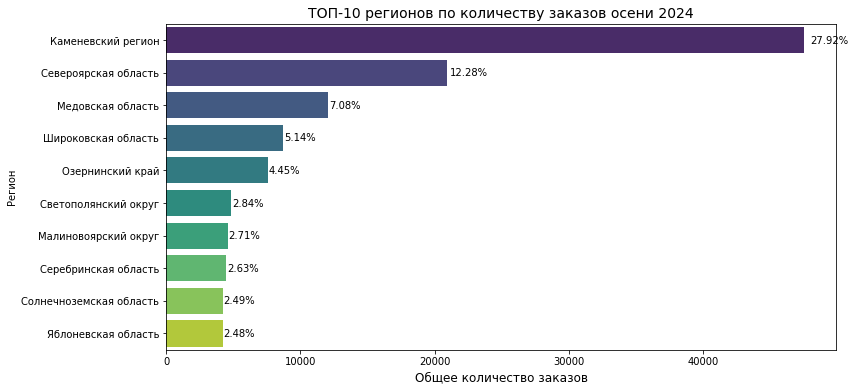

In [66]:
# Настройка размера графика
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_10_regions,
    x='total_orders',
    y='region_name',
    palette='viridis'
)

plt.title('ТОП-10 регионов по количеству заказов осени 2024', fontsize=14)
plt.xlabel('Общее количество заказов', fontsize=12)
plt.ylabel('Регион')

# Подписи с долей заказов
for index, row in top_10_regions.iterrows():
    plt.text(row['total_orders']*1.01, index, f"{row['share_orders']}%", va='center')

plt.show()

In [67]:
# ТОП 10 партнеров 
partner_stats = df_autumn.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),        # количество уникальных мероприятий
    total_orders=('order_id', 'count'),           # общее количество заказов
    total_revenue=('revenue_rub', 'sum')         # суммарная выручка в рублях
).reset_index()

partner_stats['total_revenue'] = partner_stats['total_revenue'].round(2)

# Расчет долей
partner_stats['share_events'] = (partner_stats['unique_events'] / partner_stats['unique_events'].sum() * 100).round(2)
partner_stats['share_orders'] = (partner_stats['total_orders'] / partner_stats['total_orders'].sum() * 100).round(2)
partner_stats['share_revenue'] = (partner_stats['total_revenue'] / partner_stats['total_revenue'].sum() * 100).round(2)

    
# Сортируем партнеров по метрике выручка и выбираем ТОП 10
top_10_partners = partner_stats.sort_values('total_revenue', ascending=False).head(10).reset_index(drop=True)

display(top_10_partners)

,service_name,unique_events,total_orders,total_revenue,share_events,share_orders,share_revenue
0,Билеты без проблем,2855,32788,13622236.00,16.45,19.27,15.34
1,Облачко,1413,15616,12459031.00,8.14,9.18,14.03
2,Мой билет,1013,19682,11809029.00,5.84,11.57,13.30
3,Лови билет!,3626,25871,10644953.00,20.89,15.20,11.99
4,Весь в билетах,608,9642,10170589.00,3.50,5.67,11.45
5,Билеты в руки,2474,25764,7715981.00,14.26,15.14,8.69
6,Край билетов,194,3062,3222585.25,1.12,1.80,3.63
7,Яблоко,538,3496,2831861.50,3.10,2.05,3.19
8,Прачечная,728,5831,2647691.50,4.19,3.43,2.98
9,Тебе билет!,859,3779,2223909.25,4.95,2.22,2.50


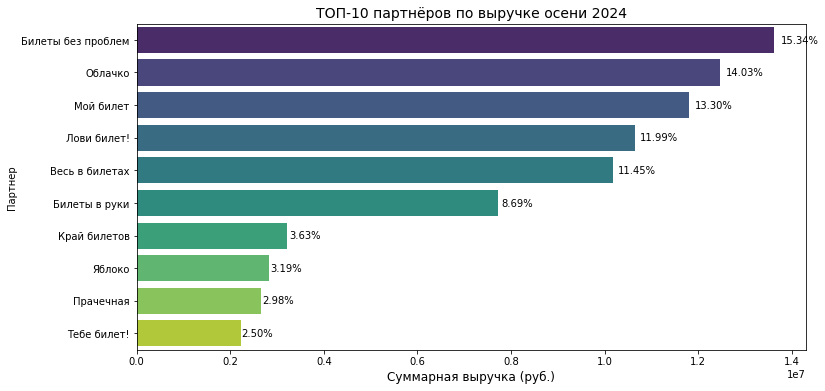

In [68]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_10_partners,
    x='total_revenue',
    y='service_name',
    palette='viridis'
)

plt.title('ТОП-10 партнёров по выручке осени 2024', fontsize=14)
plt.xlabel('Суммарная выручка (руб.)', fontsize=12)
plt.ylabel('Партнер')

# Добавляем подписи с долей выручки
for index, row in top_10_partners.iterrows():
    plt.text(row['total_revenue']*1.01, index, f"{row['share_revenue']:.2f}%", va='center')

plt.show()

`ТОП 10 регионов по числу уникальных мероприятий показывает`:
- `Каменевский регион` является явным лидером с `3946` событиями, что составляет `24.77%` от всех мероприятий, и `27.92%` всех заказов.
- `Североярская область` также активно регион, но значительно уступает по объему мероприятий `16.46%`	и заказов `12.28%`
- Остальные регионы формируют менее значимые доли ` 2–7%`.

Явный лидер - это `Каменевский регион`, на него приходится треть всех мероприятий и заказов. Остальные регионы распределяются более равномерно. Стоит обратить внимание для  продвижения событий или маркетинговых усилий на ключевые регионы-лидеры.
__________

`ТОП 10 партнеров по числу уникальных мероприятий`:

-  `Билеты без проблем` и  `Облачко`  дают самую большую выручку `15.34%` и  `14.03%` соответственно. Но при этом `Облачко` имеет меньше мероприятий `8.14%`.
- `Лови билет!` и `Билеты без проблем` —  это самые активные  партнеры по событиям и заказам.
- `Мой билет` имеет меньше мероприятий, но  при этом значительную выручку `13.30%`, что говорит о продаже дорогих билетов или крупных заказов.

Есть явные лидеры как по количеству событий, так и по выручке. Стоит  учитывать не только активность партнеров, но и общую выручку, чтобы выделить ключевых партнеров  для дальнейшего сотрудничества.
____________

## Статистический анализ данных

Проверяем 2 гипотезы, которые предполагают большую активность пользователей мобильных устройств:
- Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
- Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
_____

**Гипотеза 1 Среднее количество заказов на пользователя:**
- `H₀ (нулевая гипотеза)`: Среднее количество заказов на пользователя мобильного приложения ≤ среднему количеству заказов пользователей стационарных устройств;
- `H₁ (альтернативная гипотеза)`: Среднее количество заказов на пользователя мобильного приложения > среднему количеству заказов пользователей стационарных устройств.
_____

In [69]:
# Выбираем пользователей, которые использовали десктоп
desktop_group_users = df_autumn[df_autumn['device_type_canonical'] == 'desktop']['user_id']

# Выбираем пользователей, которые использовали мобильное приложение
mobile_group_users = df_autumn[df_autumn['device_type_canonical'] == 'mobile']['user_id']

# Находим пользователей, которые использовали и ПК, и мобильное приложение
intersection = list(set(desktop_group_users) & set(mobile_group_users))

# Выводим размеры групп и количество пересекающихся пользователей
print(f'Размер группы ПК - {desktop_group_users.nunique()}, мобильных устройств - {mobile_group_users.nunique()}')
print(f'Пересечения в группах: {len(intersection)}')

Размер группы ПК - 4907, мобильных устройств - 14241
Пересечения в группах: 3274


- Мобильная аудитория в несколько раз больше, чем ПК.
- Есть пересечения — 3 199 пользователей используют обе платформы.
- Уже при таком условии есть предпосылка использовать тест Манна-Уитни, который не требует нормальности распределений.
_______

In [70]:
# Убираем пересекающихся пользователей, чтобы группы стали независимыми
desktop_group_users = desktop_group_users[~desktop_group_users.isin(intersection)]
mobile_group_users = mobile_group_users[~mobile_group_users.isin(intersection)]

# Выводим итоговый размер групп после удаления пересечений
print(f'Итоговый размер группы ПК - {desktop_group_users.nunique()}, '
      f'мобильных устройств - {mobile_group_users.nunique()}')

Итоговый размер группы ПК - 1633, мобильных устройств - 10967


In [71]:
# Формируем группы с количеством заказов на пользователя
desktop_orders = df_autumn[df_autumn['user_id'].isin(desktop_group_users)].groupby('user_id')['order_id'].count()
mobile_orders = df_autumn[df_autumn['user_id'].isin(mobile_group_users)].groupby('user_id')['order_id'].count()

# Проверяем гипотезу
alpha = 0.05
stat1, p_value1 = mannwhitneyu(mobile_orders, desktop_orders, alternative='greater')

print("1-я гипотеза: среднее количество заказов на мобильных пользователей > ПК")
print(f"p-value = {p_value1:.5f}")

if p_value1 < alpha:
    print("Отвергаем H0, принимаем альтернативную гипотезу")
else:
    print("Не удалось отвергнуть H₀")

1-я гипотеза: среднее количество заказов на мобильных пользователей > ПК
p-value = 0.00000
Отвергаем H0, принимаем альтернативную гипотезу


Результат теста говорит нам о том, что пользователи мобильного приложения совершают больше заказов, чем пользователи ПК. Мобильная аудитория более активна по количеству заказов.
_______

**Гипотеза 2 Среднее время между заказами:**
- `H₀ (нулевая гипотеза)`: Среднее время между заказами на пользователя мобильного приложения ≤ среднему времени между заказами пользователей стационарных устройств .
- `H₁ (альтернативная гипотеза)`: Среднее время между заказами пользователей мобильного приложения > среднему вемени между заказами пользователей  стационарных устройств.
_____

In [72]:
# Формируем группы с временем между заказами, убираем пропуски
desktop_days = df_autumn[(df_autumn['user_id'].isin(desktop_group_users)) &
                         (~df_autumn['days_since_prev'].isna())]['days_since_prev']
mobile_days = df_autumn[(df_autumn['user_id'].isin(mobile_group_users)) &
                        (~df_autumn['days_since_prev'].isna())]['days_since_prev']

# Проверяем гипотезу Манна-Уитни
stat2, p_value2 = mannwhitneyu(mobile_days, desktop_days, alternative='greater')

print("2-я гипотеза: среднее время между заказами мобильных пользователей > ПК")
print(f"p-value = {p_value2:.5f}")

if p_value2 < 0.05:
    print("Отвергаем H0, принимаем альтернативную гипотезу")
else:
    print("Не удалось отвергнуть H₀")

2-я гипотеза: среднее время между заказами мобильных пользователей > ПК
p-value = 0.00000
Отвергаем H0, принимаем альтернативную гипотезу


Пользователи мобильного приложения демонстрируют отличающуюся активность по времени между заказами по сравнению с пользователямистационарных устройств.
________

## Общий вывод и рекомендации

Был проведен анализ данных сервиса `Афиша` за период с `1 июня по 30 октября 2024 года`, включавший информацию о заказах билетов, мероприятиях, пользователях, регионах и партнерах.

**Сезонность и динамика заказов**:
- Число заказов стабильно росло с июня `34 676` до октября `100 209`.
- Наибольший скачок приходится на сентябрь-октябрь, что может быть связано с сезонными мероприятиями или маркетинговыми активностями.
- Количество активных пользователей (DAU) также показывает устойчивый рост: с начала сентября показатель составлял `600–700` пользователей, к концу октября он вырос до `1100–1200`.
- Летние месяцы характеризуются высокой долей заказов на концерты `43%`, осенью  доля концертов снижается до `37,5%`, возрастает популярность театра `25%` и спорта `11%`, что говорит о смещении интересов пользователей к более спокойным мероприятиям.
- В течение осеннего периода наблюдается рост числа заказов, с ярко выраженными пиками 1 сентября, 1 октября и 31 октября, вероятно, связанными с акционными предложениями или маркетинговыми кампаниями.
- Средняя стоимость билета имеет провалы в дни с пиками числа заказов, что указывает на влияние маркетинговых скидок. После середины октября наблюдается снижение средней стоимости билета.
- Осенью наблюдается рост заказов на мероприятия для младшей аудитории и снижение для старшей (18 лет), что может отражать сезонное смещение интересов к семейным событиям.


**Пользовательская активность**:
- Наибольшая активность наблюдается во вторник, четверг и пятницу; выходные приносят меньше заказов.
- Количество заказов на пользователя также выше в будние дни, что говорит об активности в рабочии дни недели.
- 80 % заказов совершено с мобильных устройств, десктопная активность немного увеличилась осенью.

**Региональные и партнерские лидеры**:
- Среди регионов лидируют `Каменевский` и `Североярская области`, среди партнеров — `Лови билет!`, `Билеты без проблем`, `Билеты в руки`.

**Выводы по гипотезам:**
- Гипотеза о большей активности пользователей мобильных устройств подтверждается.
- Пользователи мобильных устройств активнее, чем пользователи стационарных устройств: у них больше заказов и большее среднее время между ними.

`Рекомендации`:
- 
- Планировать маркетинговые акции равномерно, чтобы избегать резких пиков и падений выручки.
- Проводить маркетинговые кампании в дни с низкой активностью (например, выходные), чтобы выравнивать поток заказов и стимулировать продажи.
- Развивать мобильные каналы для наиболее активных возрастных групп.
- Использовать данные о пользовательской активности для таргетированной рекламы и улучшения клиентского опыта.
- Анализировать динамику среднего чека и сезонные колебания для более точного ценообразования и планирования мероприятий.
- Сосредоточить усилия на ключевых регионах-лидерах для увеличения выручки, но не игнорировать менее активные регионы, где есть потенциал роста.
_____